Saved Dashboard 1
Saved Dashboard 2
Saved Dashboard 3
Saved Dashboard 5


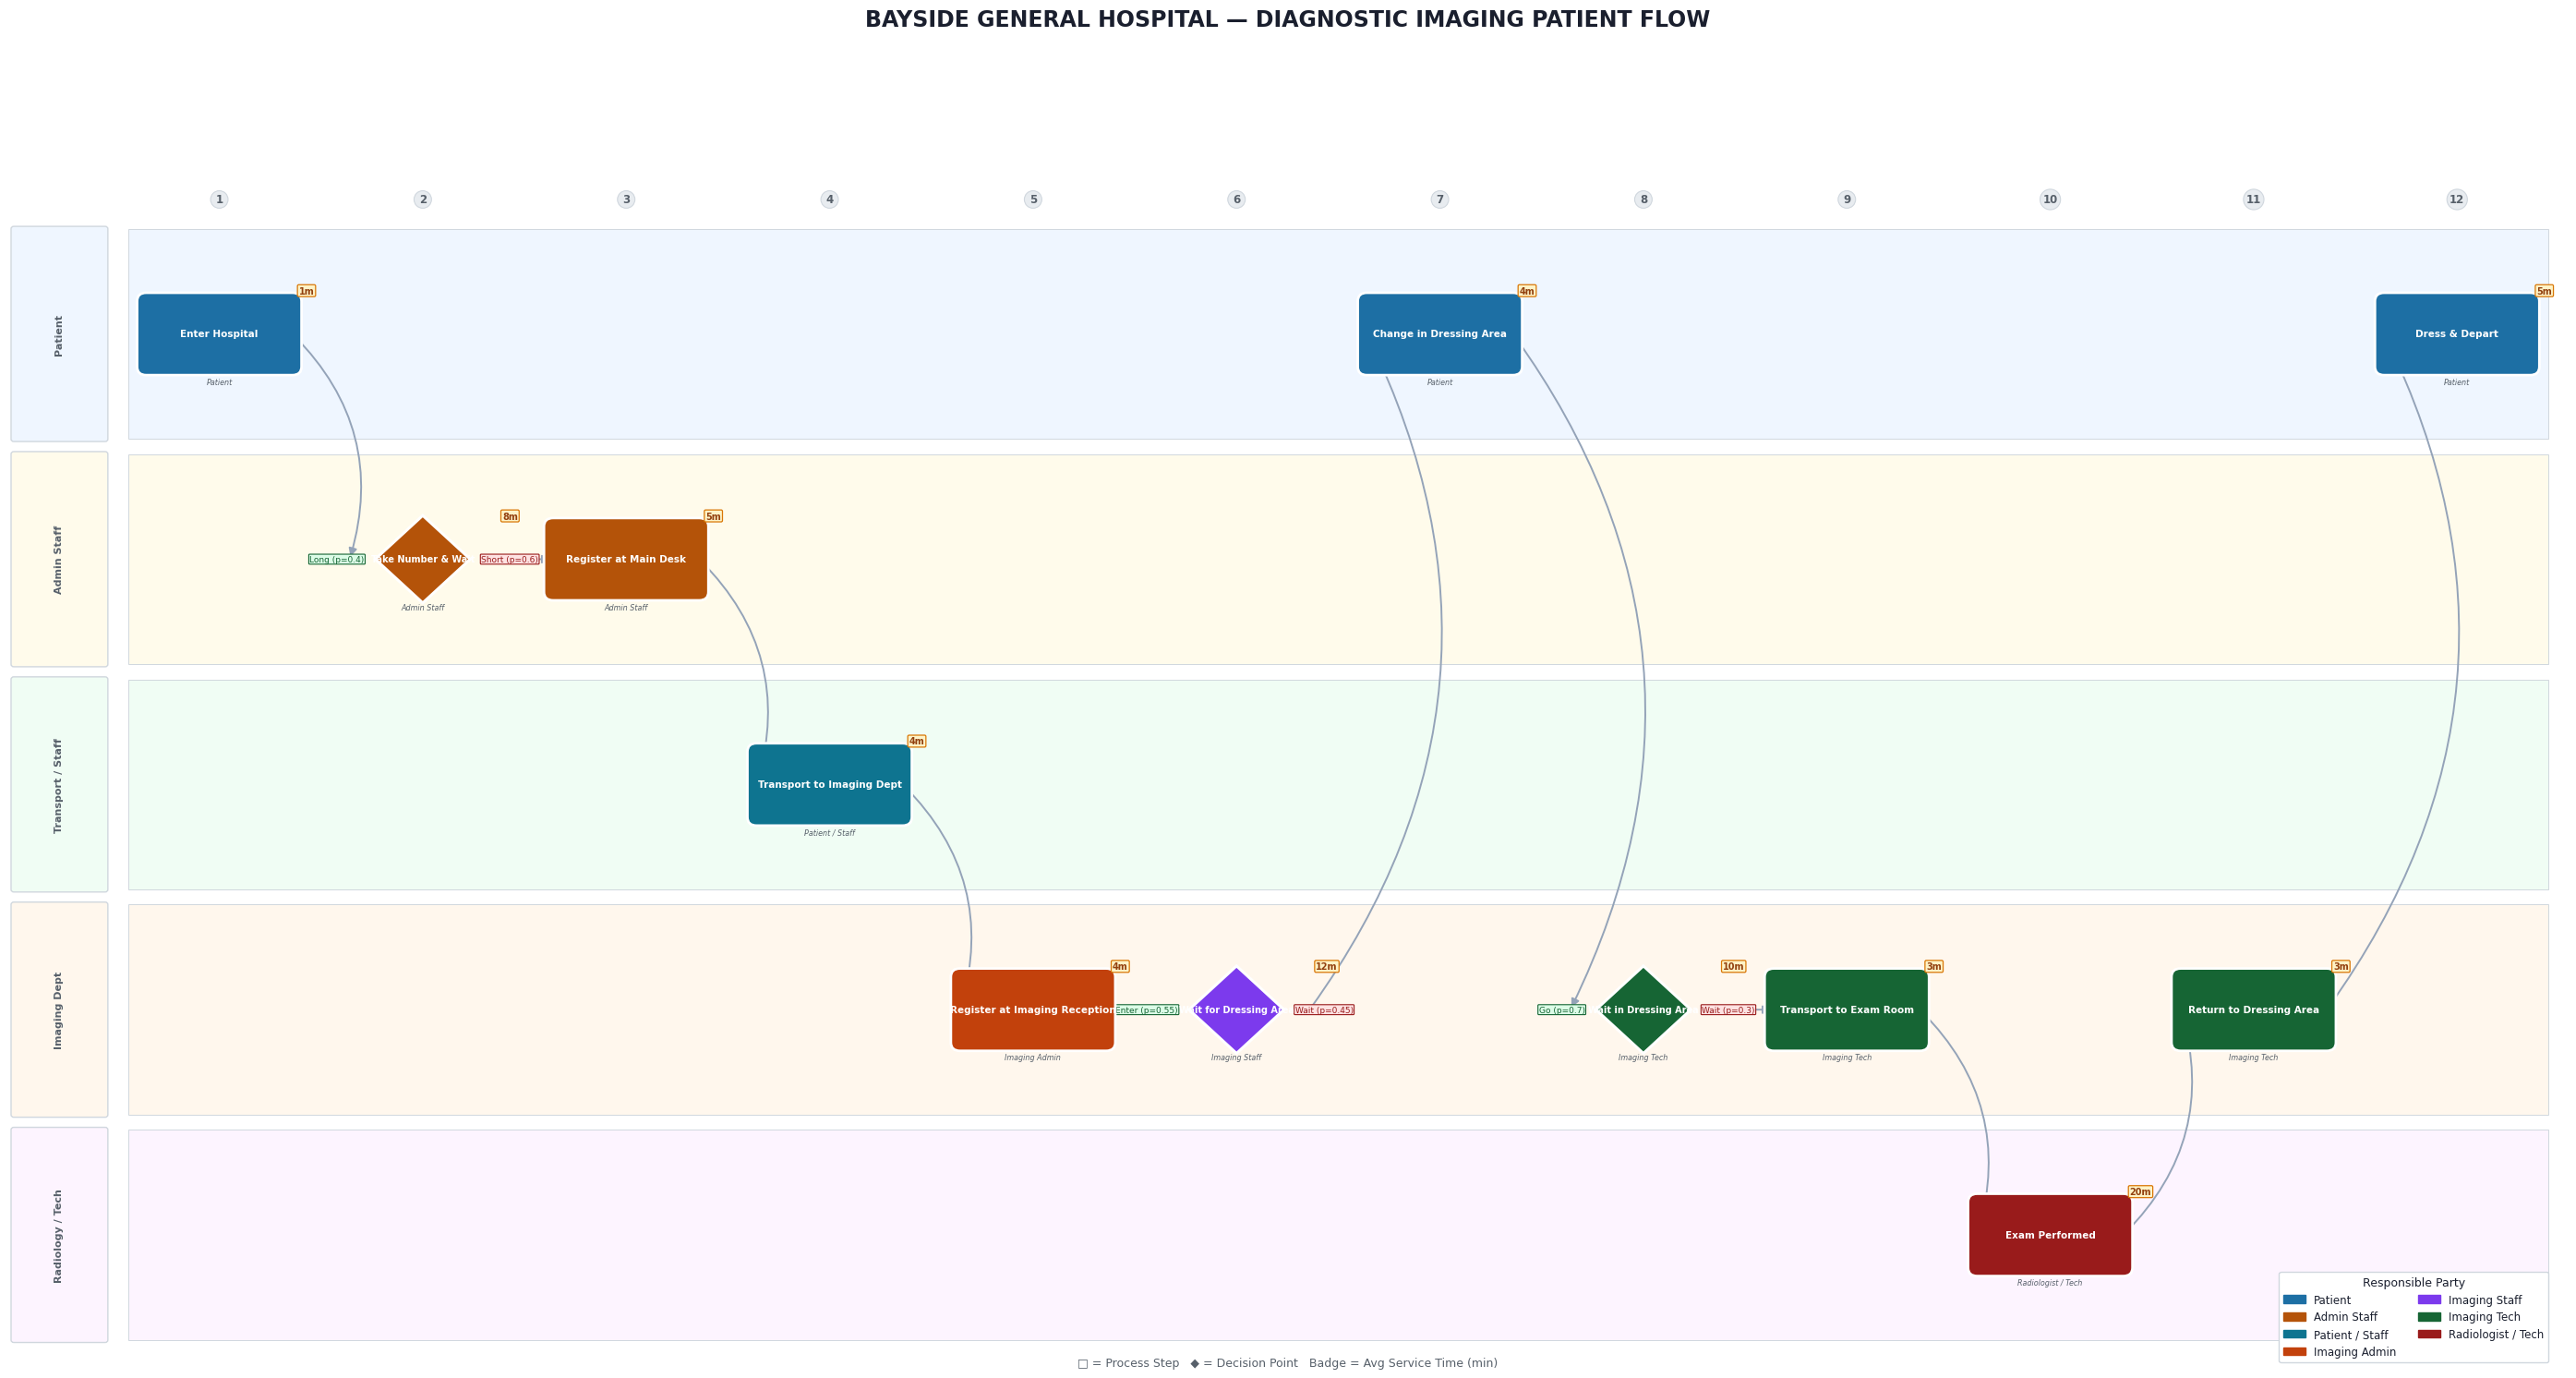

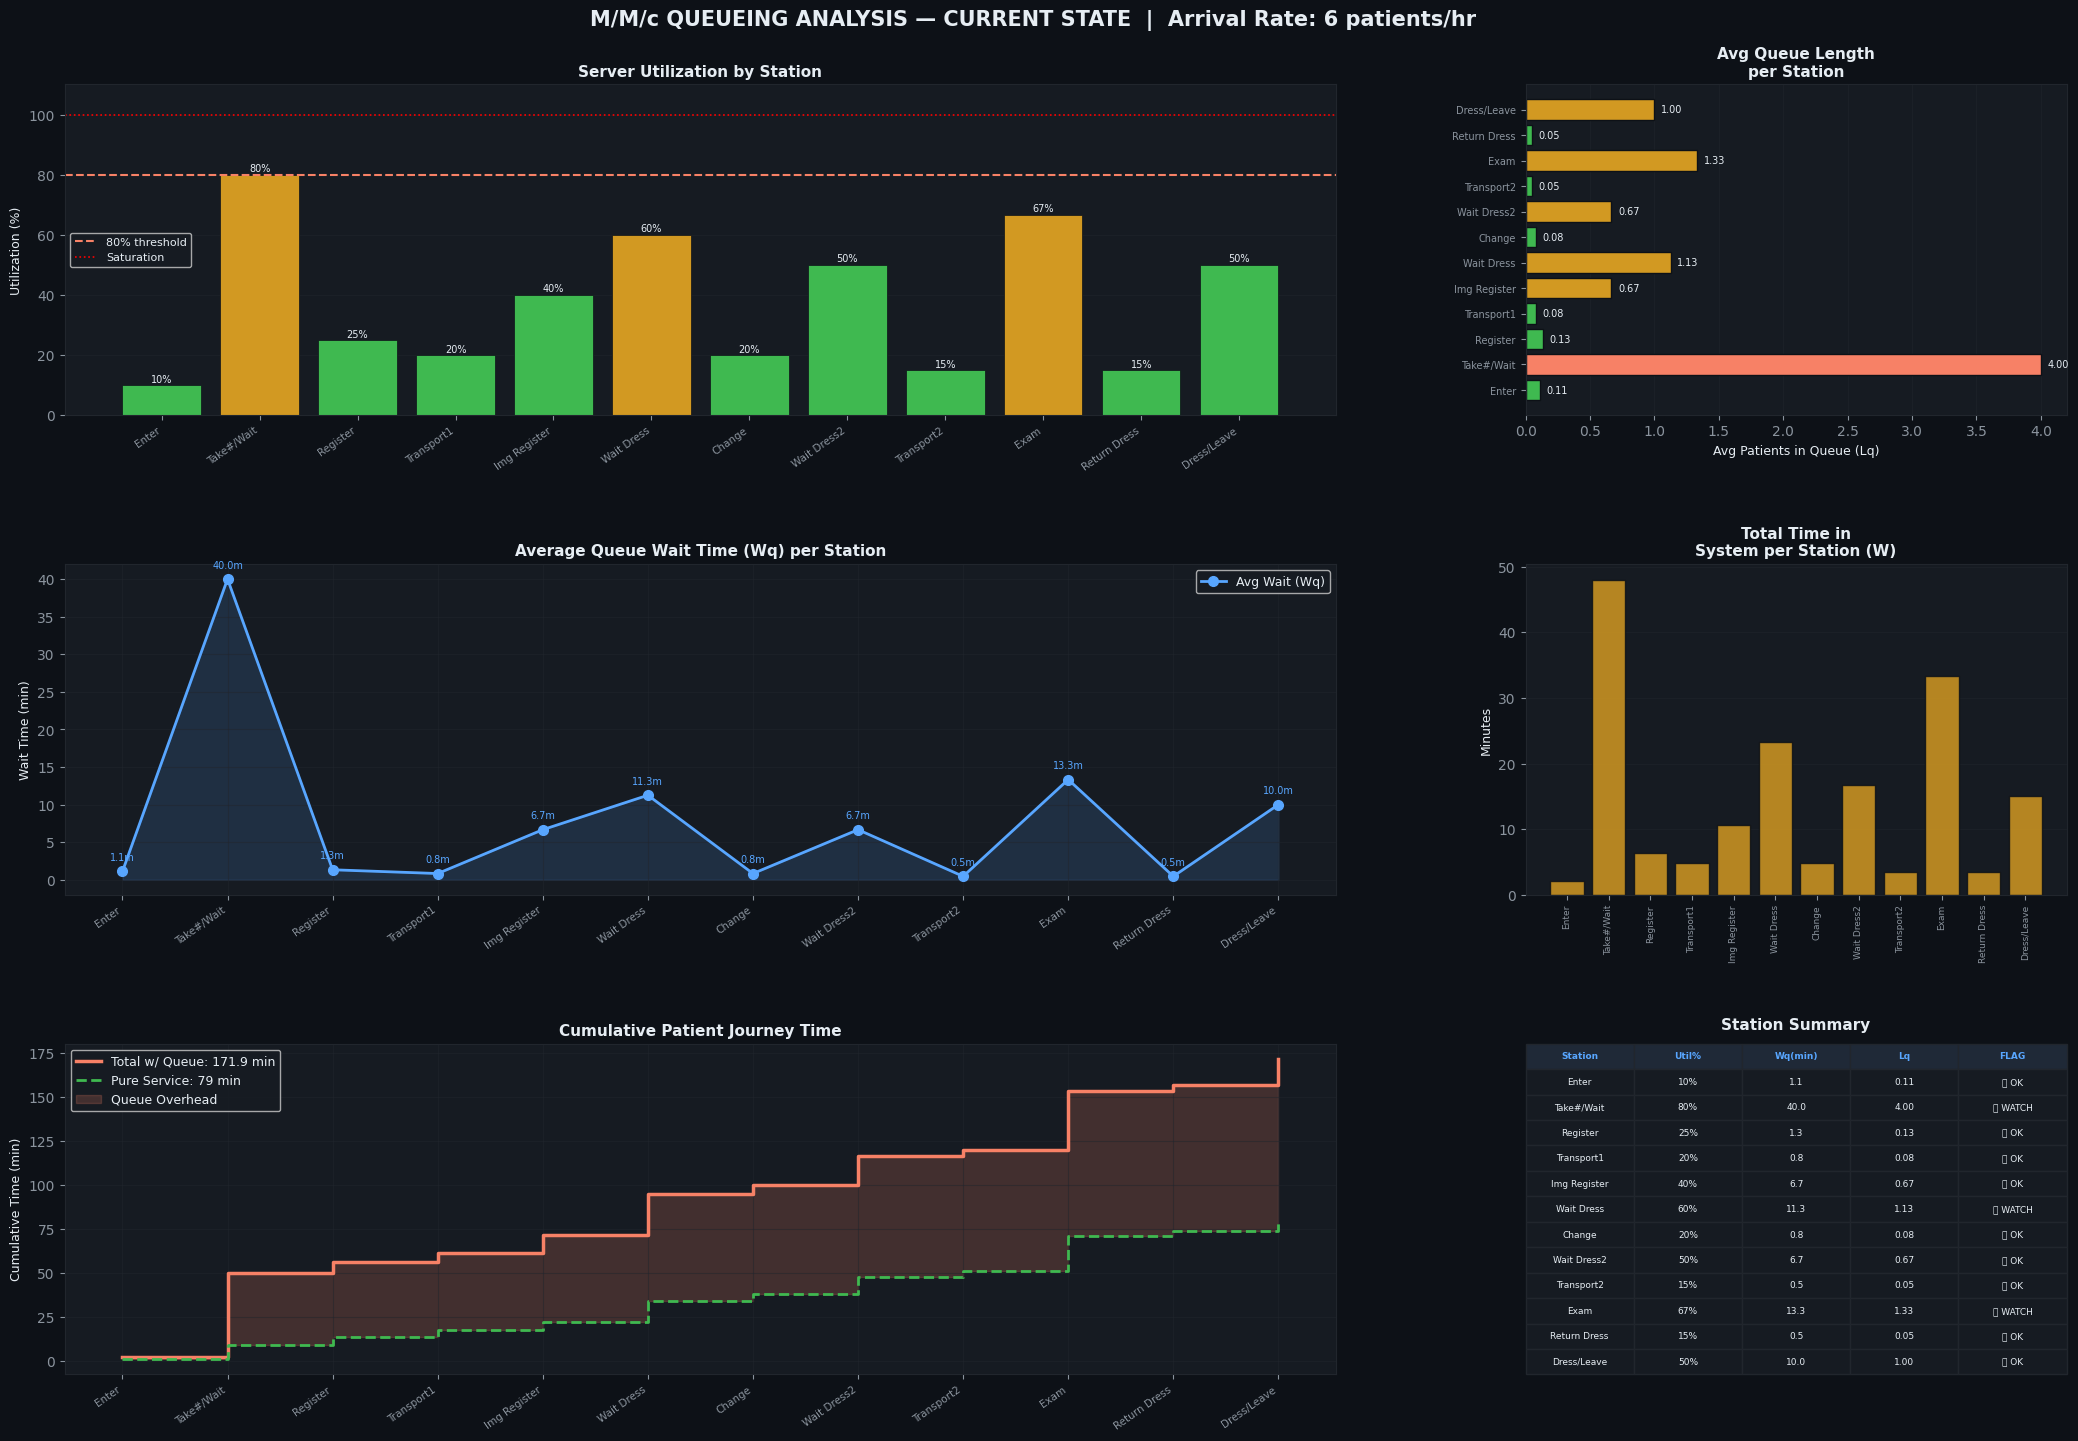

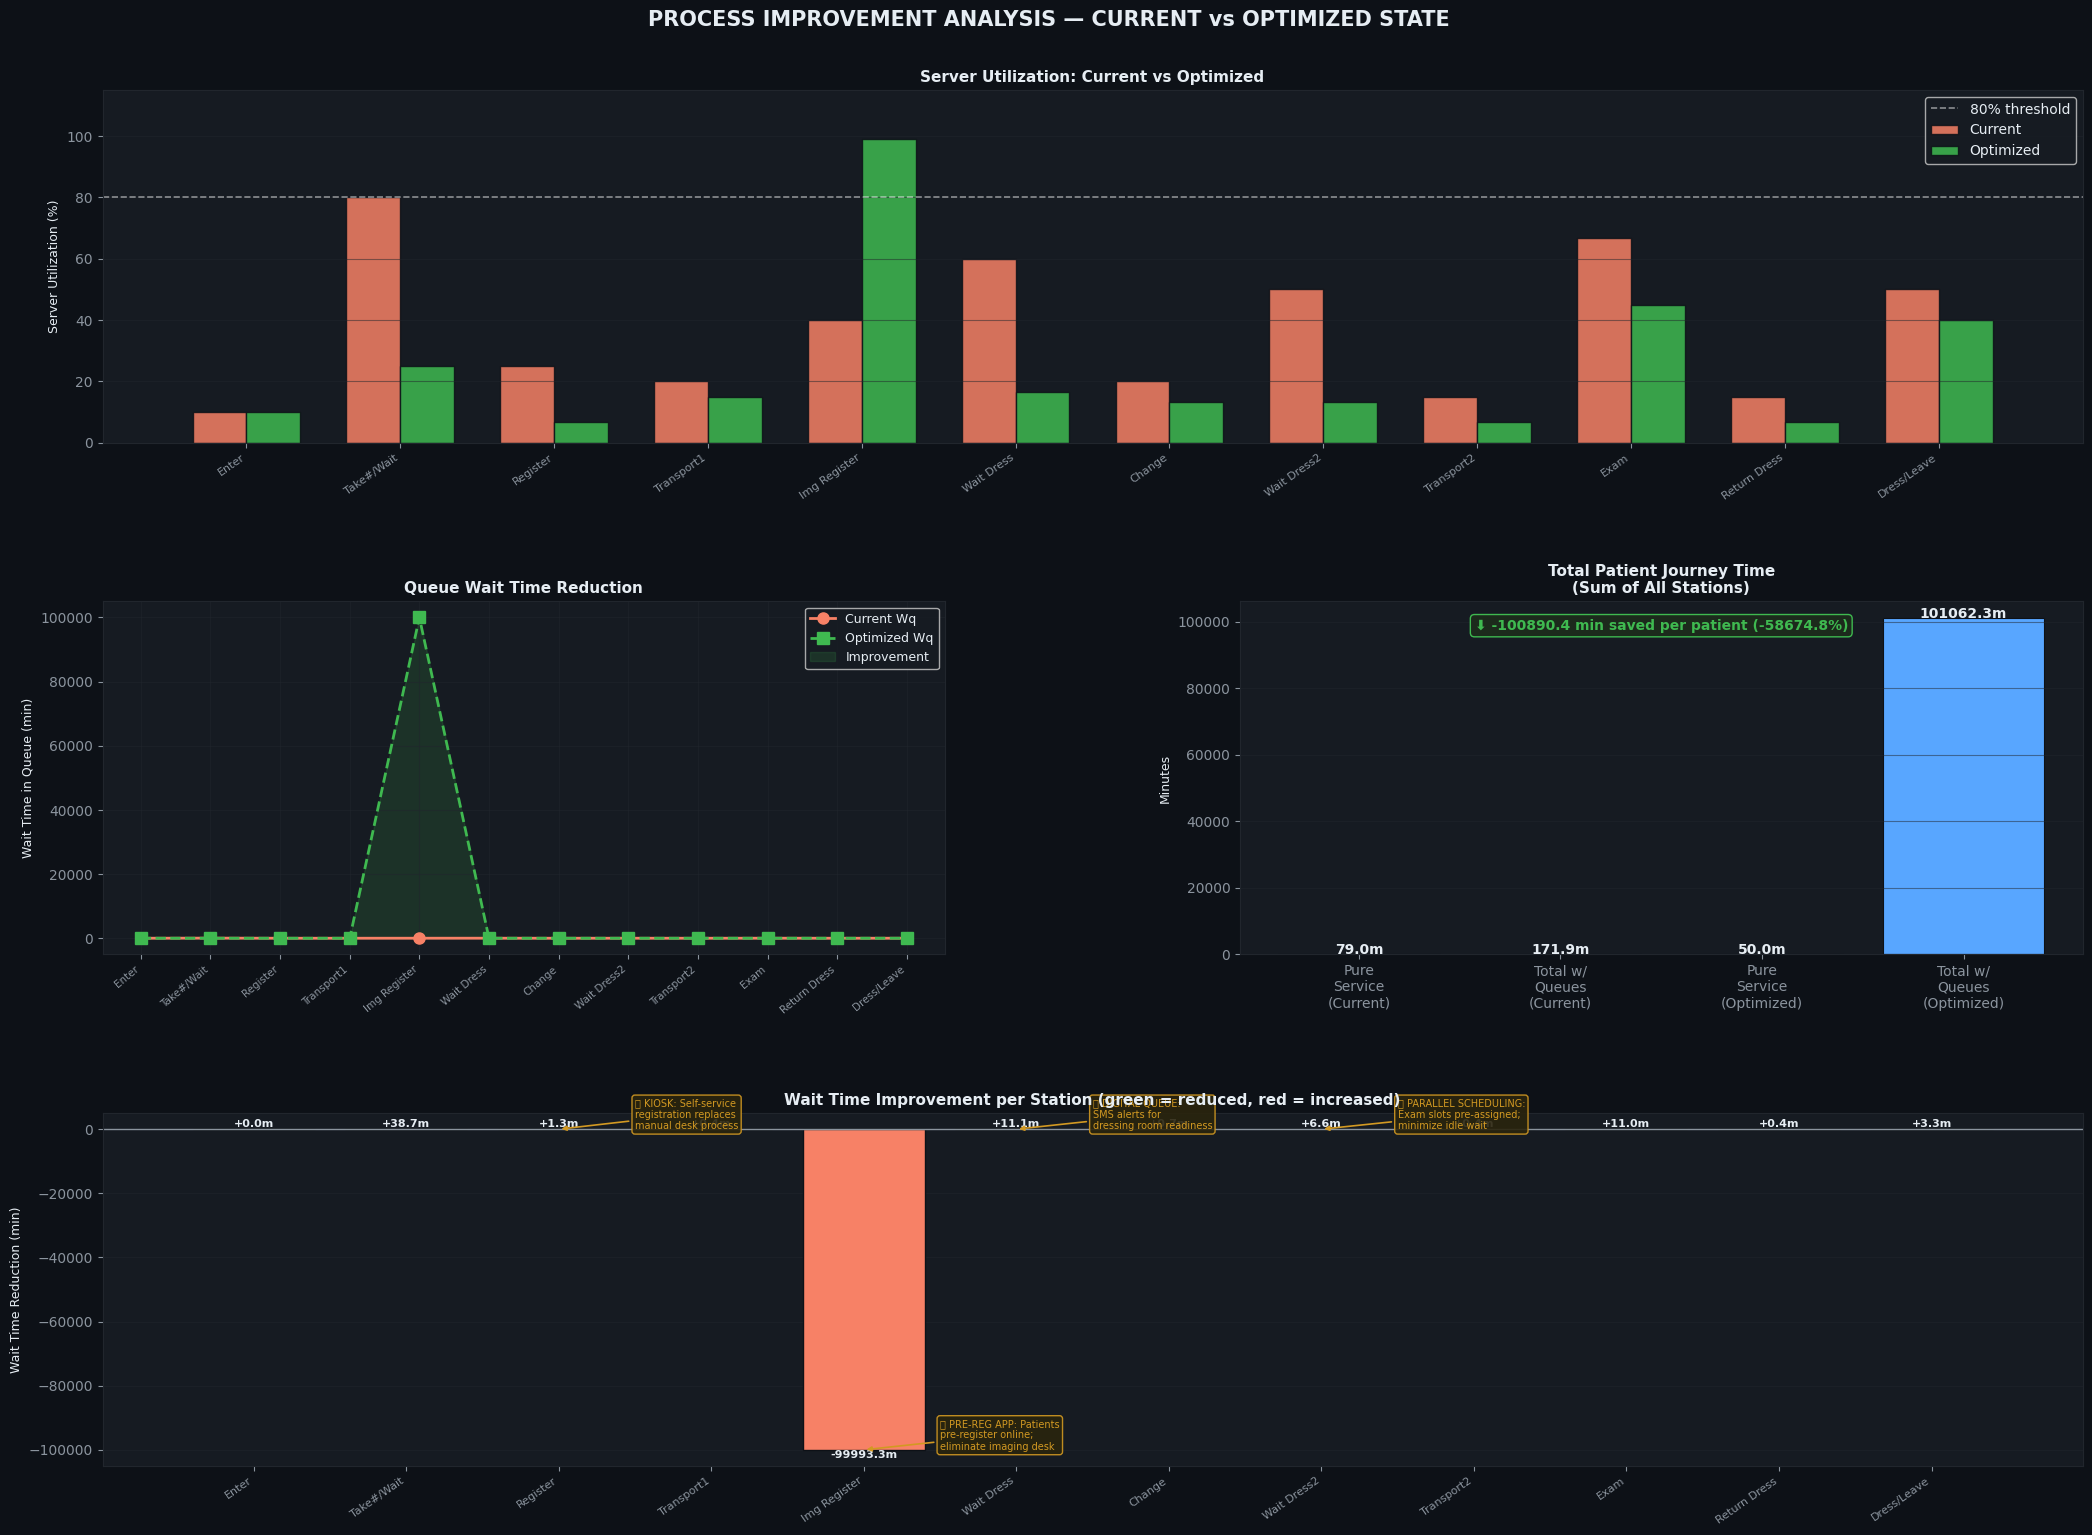

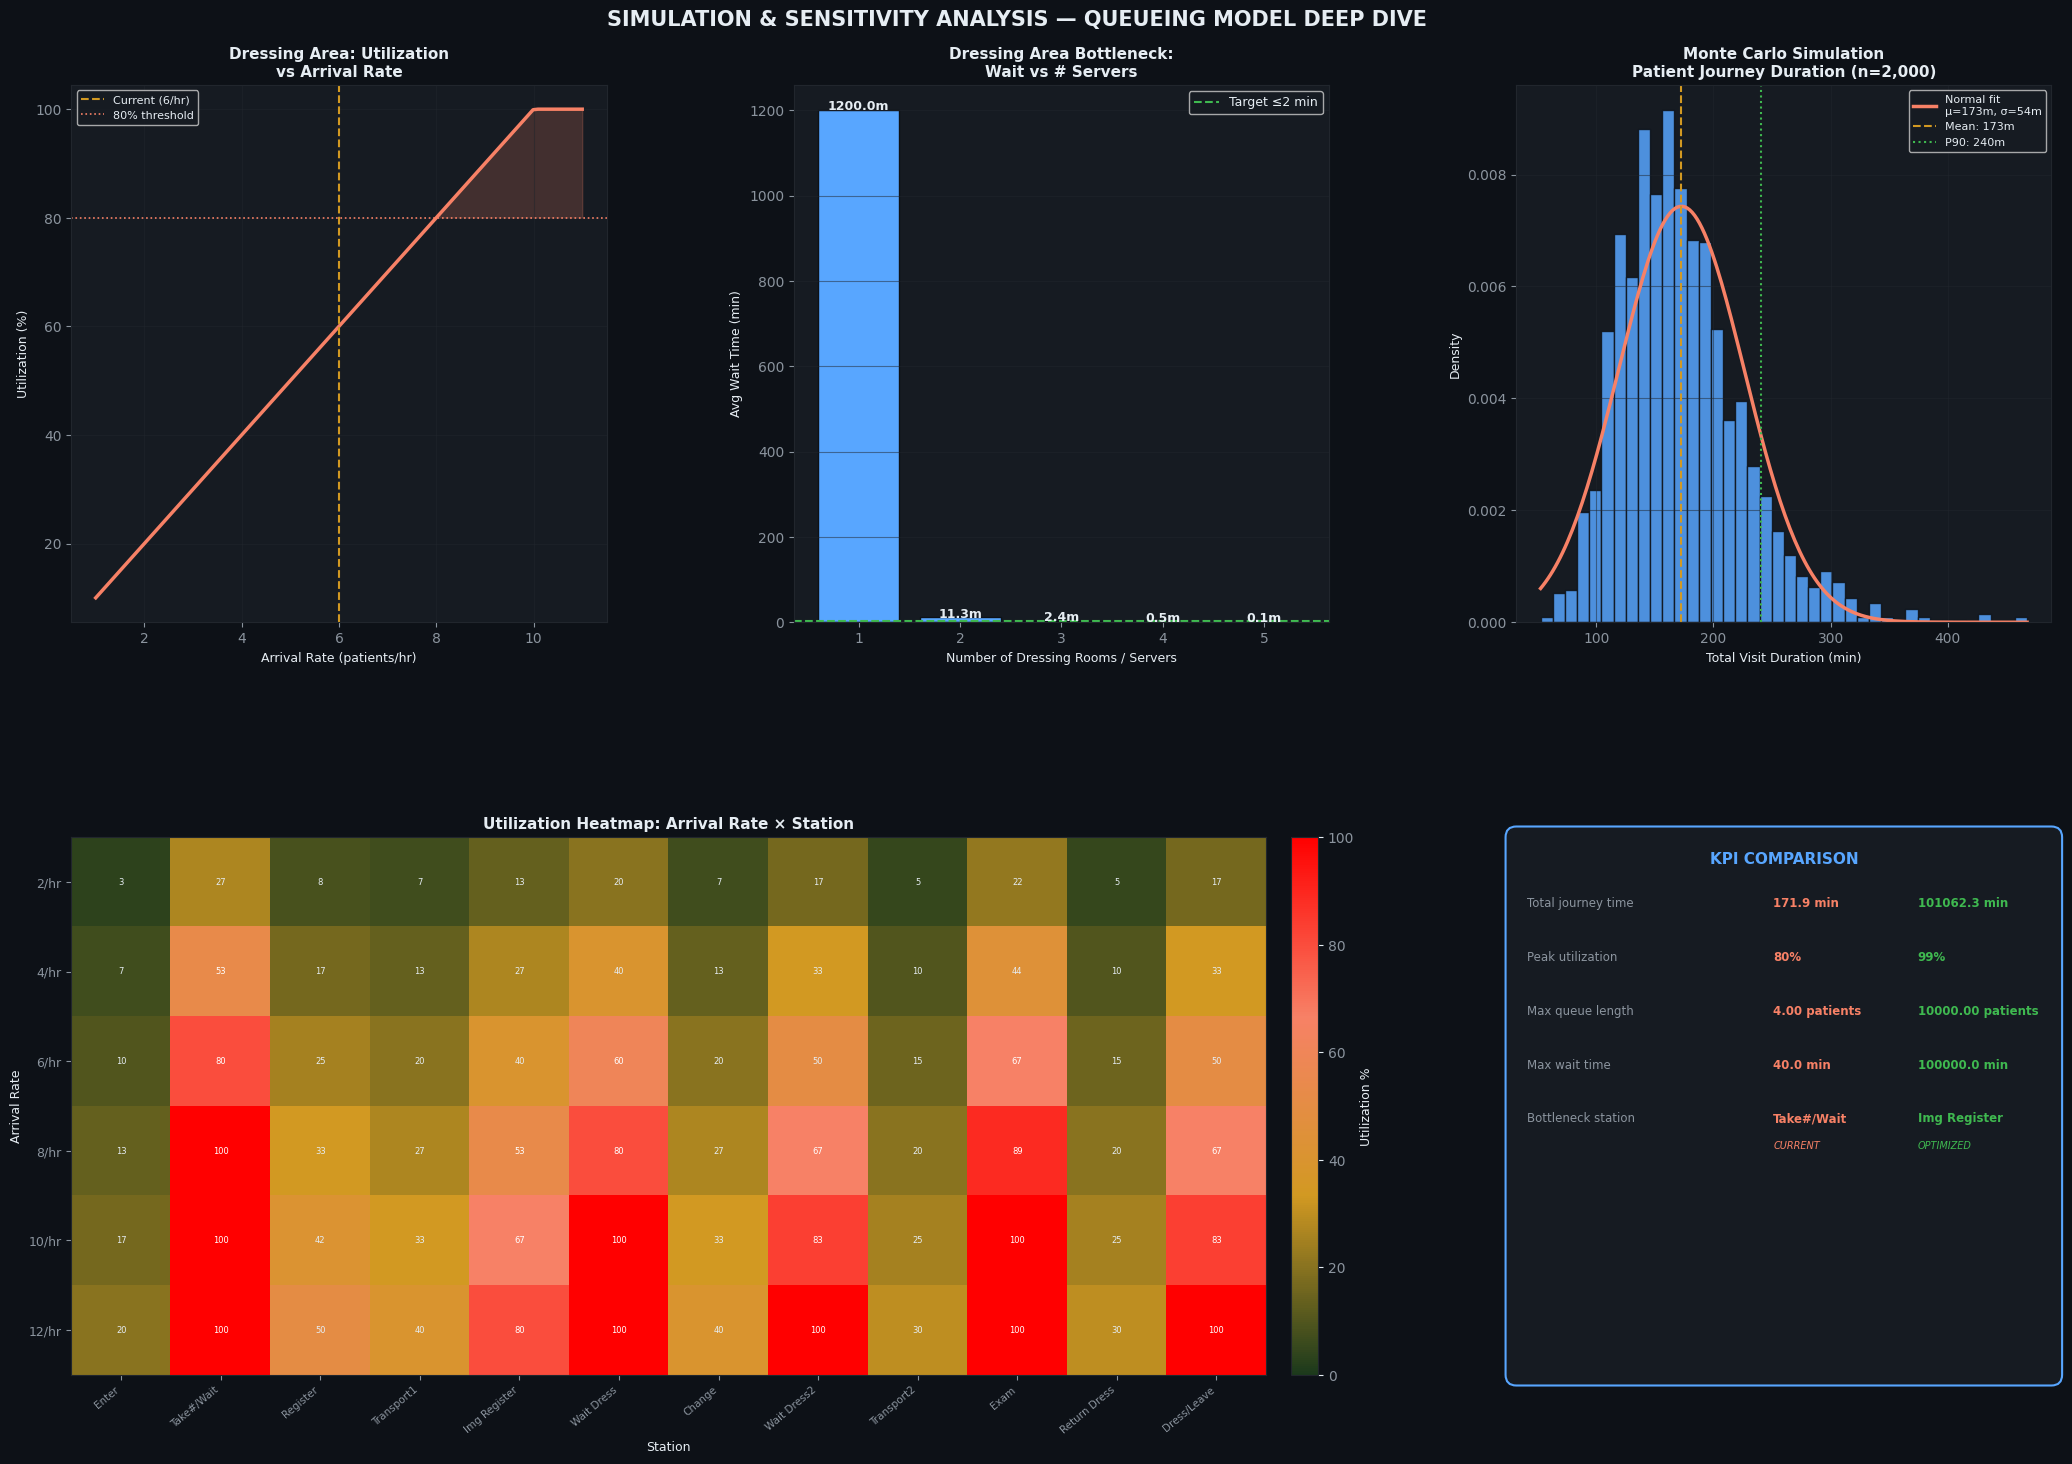

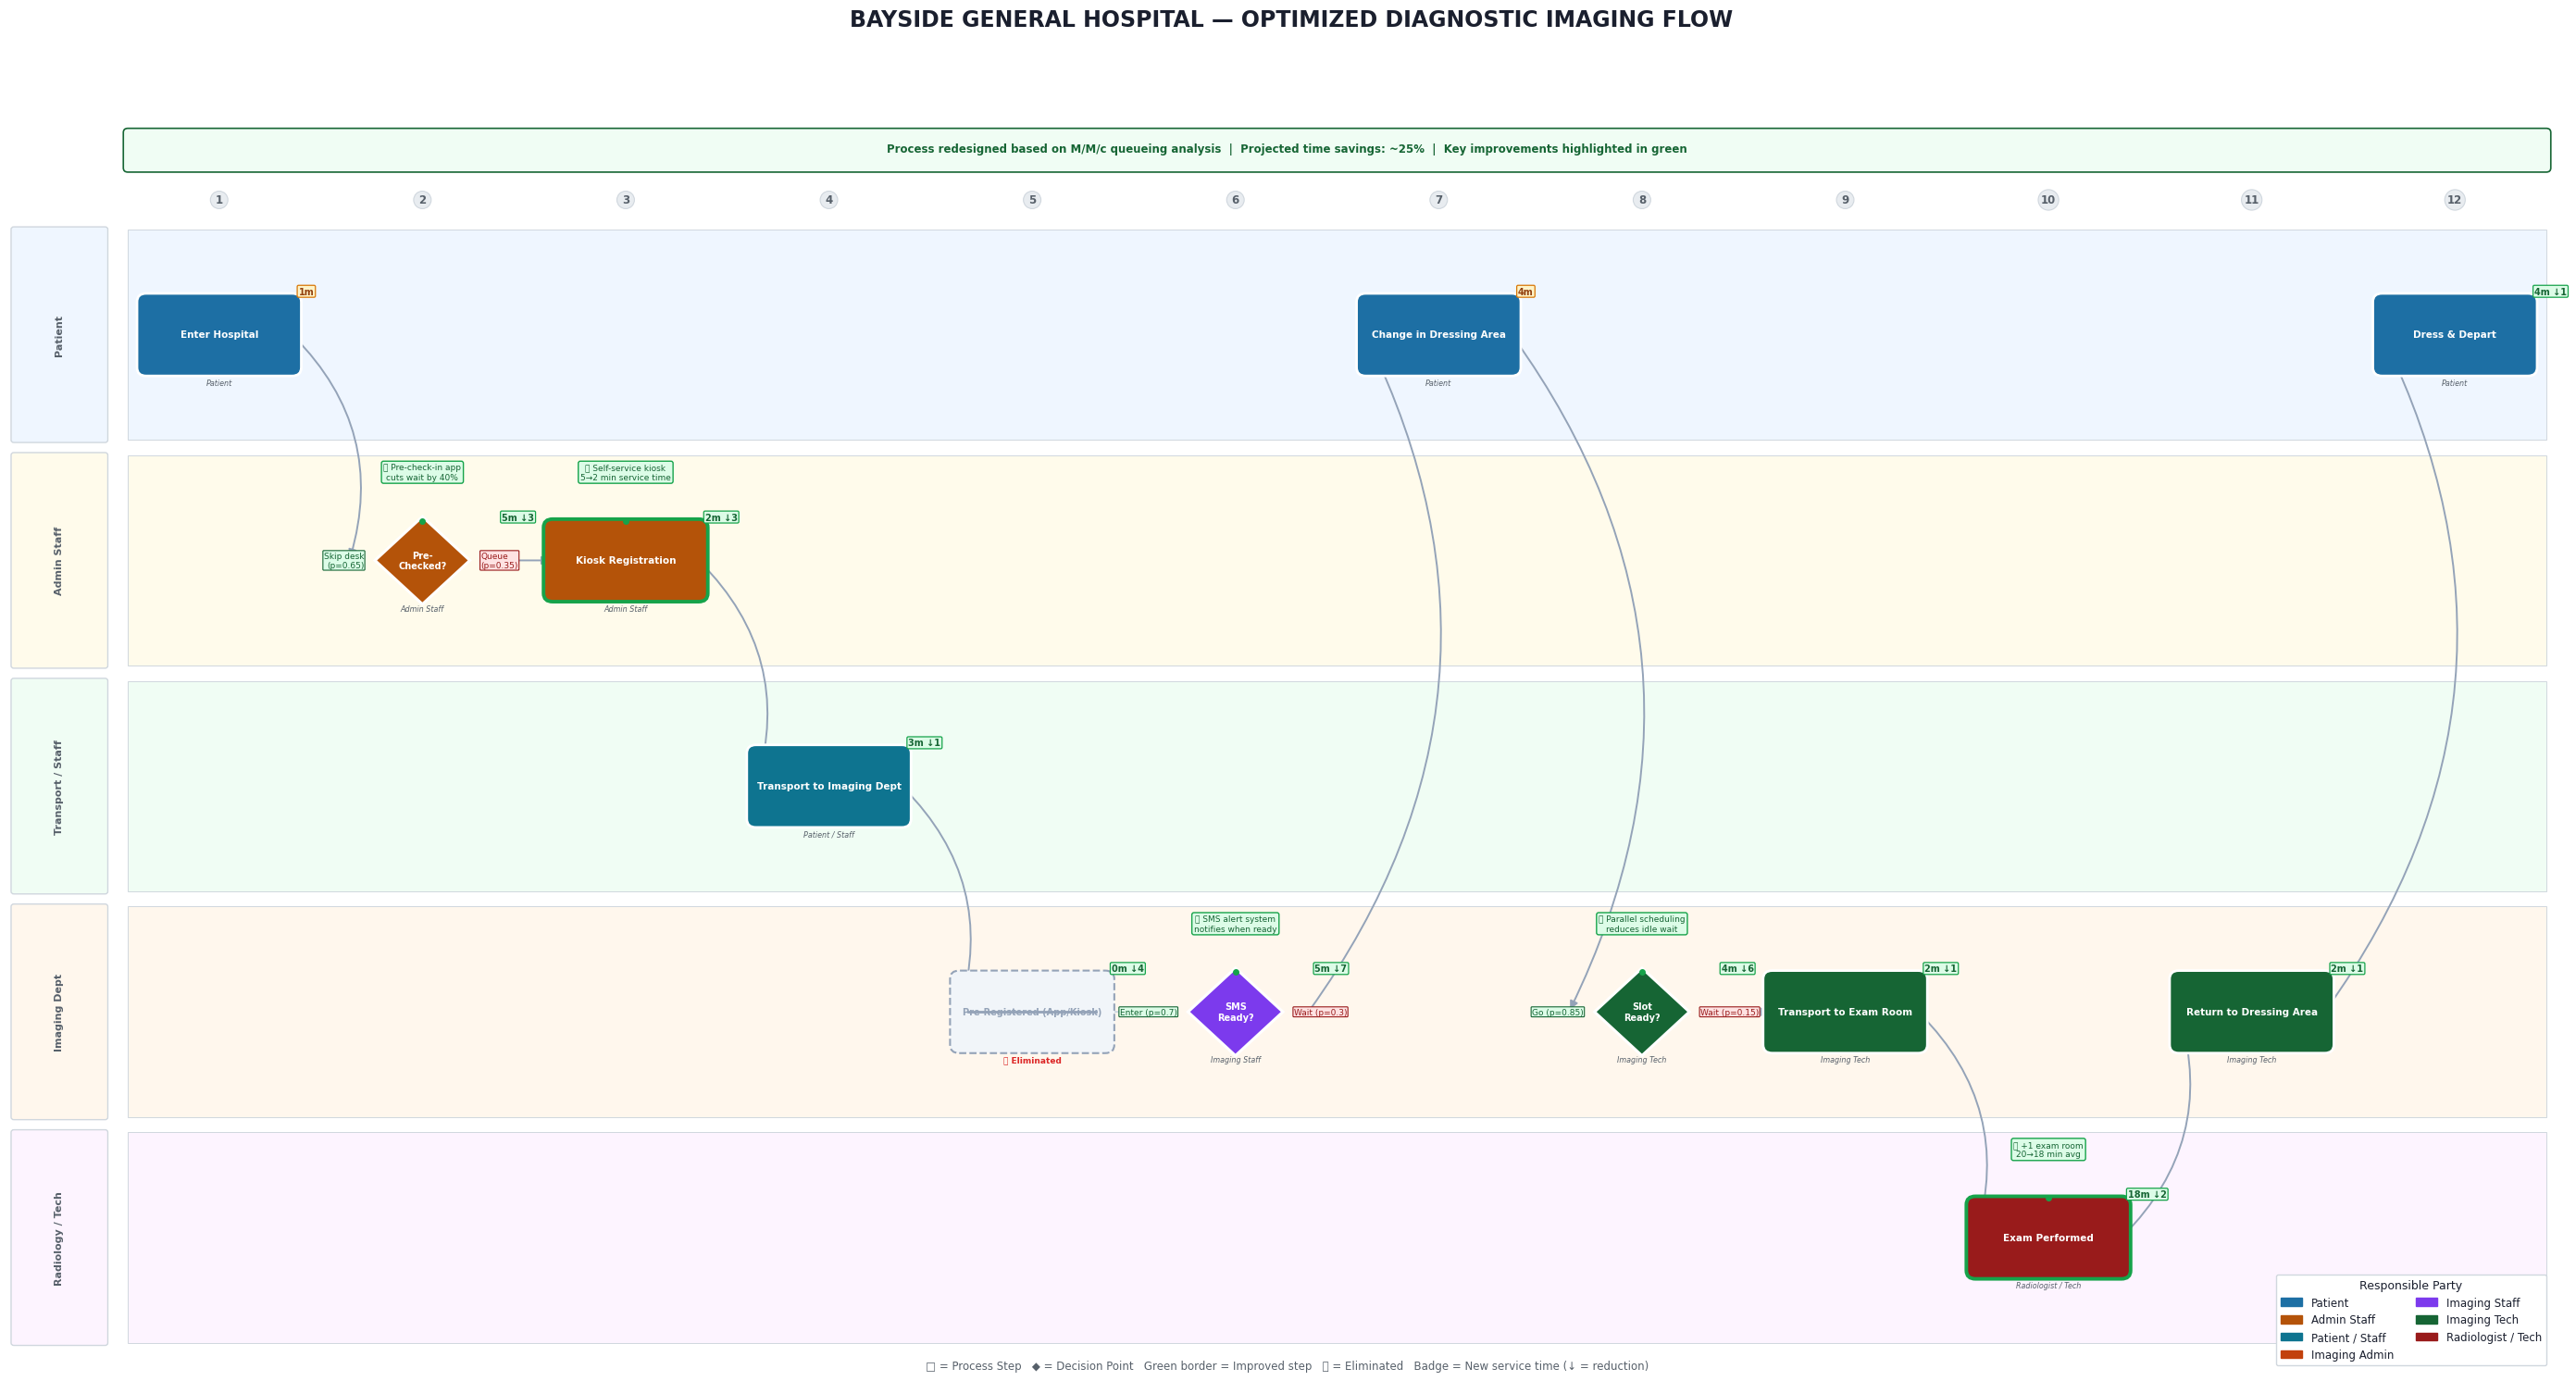

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from scipy import stats
import math
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# ─────────────────────────────────────────────
# REALISTIC ESTIMATED DATA
# ─────────────────────────────────────────────
STEPS = [
    "Enter Hospital",
    "Take Number\n& Wait",
    "Register at\nMain Desk",
    "Transport to\nImaging Dept",
    "Register at\nImaging Reception",
    "Wait for\nDressing Area",
    "Change in\nDressing Area",
    "Wait in\nDressing Area",
    "Transport to\nExam Room",
    "Exam\nPerformed",
    "Return to\nDressing Area",
    "Dress &\nDepart",
]

STEP_LABELS_SHORT = [
    "Enter", "Take#/Wait", "Register", "Transport1",
    "Img Register", "Wait Dress", "Change", "Wait Dress2",
    "Transport2", "Exam", "Return Dress", "Dress/Leave"
]

RESPONSIBLE = [
    "Patient",
    "Admin Staff",
    "Admin Staff",
    "Patient / Staff",
    "Imaging Admin",
    "Imaging Staff",
    "Patient",
    "Imaging Tech",
    "Imaging Tech",
    "Radiologist / Tech",
    "Imaging Tech",
    "Patient",
]

# Mean service times (minutes)
SERVICE_TIMES = np.array([1, 8, 5, 4, 4, 12, 4, 10, 3, 20, 3, 5])
# Arrival rate (patients/hour) — outpatient clinic, moderate load
LAMBDA_PER_HOUR = 6  # patients arrive per hour on average
LAMBDA = LAMBDA_PER_HOUR / 60  # per minute

# Number of servers per station
N_SERVERS = np.array([1, 1, 2, 2, 1, 2, 2, 2, 2, 3, 2, 1])

# Identify which steps are "queues" (waiting) vs "service"
IS_WAIT = np.array([False, True, False, False, False, True, False, True, False, False, False, False])

# ─────────────────────────────────────────────
# M/M/c QUEUEING MODEL CALCULATIONS
# ─────────────────────────────────────────────
def erlang_c(rho, c):
    """Erlang-C formula for M/M/c queue."""
    a = rho * c
    sum_terms = sum((a**n) / math.factorial(n) for n in range(c))
    last_term = (a**c) / (math.factorial(c) * (1 - rho))
    P0 = 1 / (sum_terms + last_term)
    Cq = ((a**c) / (math.factorial(c) * (1 - rho))) * P0
    return P0, Cq

def mmc_metrics(lam, mu, c):
    """Returns Lq, Wq, L, W, rho for M/M/c."""
    if mu <= 0 or c <= 0:
        return None
    rho = lam / (c * mu)
    if rho >= 1:
        rho = 0.99  # saturated
    a = lam / mu
    P0, Cq = erlang_c(a / c, c)
    Wq = Cq / (lam * (1 - rho))  # avg wait time in queue
    W = Wq + 1 / mu               # avg time in system
    Lq = lam * Wq
    L = lam * W
    utilization = rho * 100
    return {"rho": rho, "utilization": utilization,
            "Lq": Lq, "Wq": Wq, "L": L, "W": W,
            "P0": P0, "Cq": Cq}

# Compute per-station metrics
MU = 1 / SERVICE_TIMES  # service rate per server
results = []
for i in range(len(STEPS)):
    c = int(N_SERVERS[i])
    m = mmc_metrics(LAMBDA, MU[i], c)
    if m:
        results.append(m)
    else:
        results.append({"rho": 0, "utilization": 0, "Lq": 0, "Wq": 0, "L": 0, "W": 0})

df = pd.DataFrame(results)
df["step"] = STEPS
df["short"] = STEP_LABELS_SHORT
df["service_time"] = SERVICE_TIMES
df["n_servers"] = N_SERVERS
df["responsible"] = RESPONSIBLE
df["is_wait"] = IS_WAIT
df["total_time"] = df["W"]  # time at station

# ─────────────────────────────────────────────
# IMPROVED PROCESS — proposed changes
# ─────────────────────────────────────────────
# Improvements:
# 1. Self-service kiosk for main registration (reduces service time 5→2 min, servers 2→3)
# 2. Pre-registration via app eliminates imaging reception step (merge with step 2)
# 3. Digital dressing room queue mgmt (reduces wait, servers +1)
# 4. Automated transport notification reduces transport time
# 5. Parallel exam scheduling reduces wait in dressing area

SERVICE_TIMES_IMP = np.array([1, 5, 2, 3, 0, 5, 4, 4, 2, 18, 2, 4])
N_SERVERS_IMP     = np.array([1, 2, 3, 2, 1, 3, 3, 3, 3, 4, 3, 1])
STEPS_IMP = [s if s != "Register at\nImaging Reception" else "Pre-Registered\n(App/Kiosk)" for s in STEPS]

results_imp = []
for i in range(len(STEPS)):
    c = int(N_SERVERS_IMP[i])
    mu_i = 1 / SERVICE_TIMES_IMP[i] if SERVICE_TIMES_IMP[i] > 0 else 0.001
    m = mmc_metrics(LAMBDA, mu_i, c)
    if m:
        results_imp.append(m)
    else:
        results_imp.append({"rho": 0, "utilization": 0, "Lq": 0, "Wq": 0, "L": 0, "W": 0})

df_imp = pd.DataFrame(results_imp)
df_imp["step"] = STEPS_IMP
df_imp["short"] = STEP_LABELS_SHORT
df_imp["service_time"] = SERVICE_TIMES_IMP
df_imp["n_servers"] = N_SERVERS_IMP
df_imp["total_time"] = df_imp["W"]

# ─────────────────────────────────────────────
# COLOR PALETTE
# ─────────────────────────────────────────────
BG        = "#0d1117"
PANEL_BG  = "#161b22"
ACCENT1   = "#58a6ff"   # blue
ACCENT2   = "#f78166"   # coral/red
ACCENT3   = "#3fb950"   # green
ACCENT4   = "#d29922"   # gold
TEXT_MAIN = "#e6edf3"
TEXT_SUB  = "#8b949e"
GRID_CLR  = "#21262d"

RESP_COLORS = {
    "Patient":              "#58a6ff",
    "Admin Staff":          "#d29922",
    "Patient / Staff":      "#79c0ff",
    "Imaging Admin":        "#f0883e",
    "Imaging Staff":        "#e8a0f0",
    "Imaging Tech":         "#3fb950",
    "Radiologist / Tech":   "#f78166",
}

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   PANEL_BG,
    "axes.edgecolor":   GRID_CLR,
    "axes.labelcolor":  TEXT_MAIN,
    "xtick.color":      TEXT_SUB,
    "ytick.color":      TEXT_SUB,
    "text.color":       TEXT_MAIN,
    "grid.color":       GRID_CLR,
    "grid.alpha":       0.5,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   11,
    "axes.labelsize":   9,
})

# ═══════════════════════════════════════════════════════════════
# DASHBOARD 1 — PROCESS FLOW CHART (LIGHT THEME)
# ═══════════════════════════════════════════════════════════════
FG_BG      = "white"
FG_BORDER  = "#d0d7de"
FG_TEXT    = "#1a1f2e"
FG_SUBTEXT = "#57606a"
FG_GRID    = "#e8ecf0"

RESP_COLORS_LIGHT = {
    "Patient":              "#1d6fa4",
    "Admin Staff":          "#b45309",
    "Patient / Staff":      "#0e7490",
    "Imaging Admin":        "#c2410c",
    "Imaging Staff":        "#7c3aed",
    "Imaging Tech":         "#166534",
    "Radiologist / Tech":   "#991b1b",
}

LANE_BG_LIGHT = {
    "Patient":           "#eff6ff",
    "Admin Staff":       "#fffbeb",
    "Transport / Staff": "#f0fdf4",
    "Imaging Dept":      "#fff7ed",
    "Radiology / Tech":  "#fdf4ff",
}

LANE_H   = 2.5
LANE_PAD = 0.18
N_LANES  = 5
CANVAS_H = N_LANES * LANE_H + (N_LANES + 1) * LANE_PAD + 1.6

LANES_LIGHT = {}
lane_names_ordered = ["Radiology / Tech", "Imaging Dept", "Transport / Staff", "Admin Staff", "Patient"]
for idx, name in enumerate(lane_names_ordered):
    y0 = LANE_PAD + idx * (LANE_H + LANE_PAD)
    LANES_LIGHT[name] = (y0, y0 + LANE_H)

fig1, ax1 = plt.subplots(figsize=(28, CANVAS_H), facecolor=FG_BG)
ax1.set_facecolor(FG_BG)
CANVAS_W = 28.0
ax1.set_xlim(0, CANVAS_W)
ax1.set_ylim(0, CANVAS_H)
ax1.axis("off")
fig1.suptitle("BAYSIDE GENERAL HOSPITAL — DIAGNOSTIC IMAGING PATIENT FLOW",
              fontsize=17, fontweight="bold", color=FG_TEXT, y=0.98)

LANE_LABEL_W = 1.0
CHART_X0 = LANE_LABEL_W + 0.3
CHART_X1 = CANVAS_W - 0.2

for lane, (y0, y1) in LANES_LIGHT.items():
    lc = LANE_BG_LIGHT[lane]
    # label strip
    ax1.add_patch(FancyBboxPatch((0.05, y0), LANE_LABEL_W, y1 - y0,
                                  boxstyle="round,pad=0.03",
                                  facecolor=lc, edgecolor=FG_BORDER, lw=1.0, zorder=1))
    ax1.text(0.05 + LANE_LABEL_W/2, (y0+y1)/2, lane,
             fontsize=8, color=FG_SUBTEXT, va="center", ha="center",
             rotation=90, fontweight="bold")
    # content strip
    ax1.add_patch(FancyBboxPatch((CHART_X0, y0), CHART_X1 - CHART_X0, y1 - y0,
                                  boxstyle="square,pad=0",
                                  facecolor=lc, edgecolor=FG_BORDER, lw=0.7, zorder=0))

def lane_y_light(responsible):
    lane_map = {
        "Patient":            "Patient",
        "Admin Staff":        "Admin Staff",
        "Patient / Staff":    "Transport / Staff",
        "Imaging Admin":      "Imaging Dept",
        "Imaging Staff":      "Imaging Dept",
        "Imaging Tech":       "Imaging Dept",
        "Radiologist / Tech": "Radiology / Tech",
    }
    lane = lane_map.get(responsible, "Patient")
    y0, y1 = LANES_LIGHT[lane]
    return (y0 + y1) / 2

COLS_L = np.linspace(CHART_X0 + 1.0, CHART_X1 - 1.0, 12)
BOX_W2, BOX_H2 = 1.6, 0.78
DIA2 = 0.52

DECISION_STEPS = {
    1:  {"label": "Wait?",       "yes": "Long (p=0.4)",   "no": "Short (p=0.6)"},
    5:  {"label": "Room\nAvail?","yes": "Enter (p=0.55)", "no": "Wait (p=0.45)"},
    7:  {"label": "Exam\nReady?","yes": "Go (p=0.7)",    "no": "Wait (p=0.3)"},
}

NODE_POSITIONS = {}
for i, (col, resp) in enumerate(zip(COLS_L, RESPONSIBLE)):
    NODE_POSITIONS[i] = (col, lane_y_light(resp))

for i in range(len(STEPS)):
    x, y = NODE_POSITIONS[i]
    is_dec = i in DECISION_STEPS
    rc = RESP_COLORS_LIGHT.get(RESPONSIBLE[i], "#1d6fa4")
    lbl = STEPS[i].replace("\n", " ")

    if is_dec:
        ax1.add_patch(plt.Polygon(
            [[x, y+DIA2],[x+DIA2,y],[x,y-DIA2],[x-DIA2,y]],
            closed=True, facecolor=rc, edgecolor="white", lw=2.2, zorder=4))
        ax1.text(x, y, lbl, ha="center", va="center", fontsize=7,
                 color="white", fontweight="bold", zorder=5)
    else:
        ax1.add_patch(FancyBboxPatch((x-BOX_W2/2, y-BOX_H2/2), BOX_W2, BOX_H2,
                                     boxstyle="round,pad=0.1",
                                     facecolor=rc, edgecolor="white",
                                     lw=2.0, zorder=4))
        ax1.text(x, y, lbl, ha="center", va="center", fontsize=7.5,
                 color="white", fontweight="bold", zorder=5)

    # Responsible italic label
    ax1.text(x, y - BOX_H2/2 - 0.13, RESPONSIBLE[i],
             ha="center", va="top", fontsize=5.8, color=FG_SUBTEXT, style="italic")

    # Service time badge
    ax1.text(x + BOX_W2/2 + 0.07, y + BOX_H2/2 + 0.07,
             f"{SERVICE_TIMES[i]}m", ha="left", va="bottom",
             fontsize=7, color="#92400e", fontweight="bold", zorder=6,
             bbox=dict(boxstyle="round,pad=0.15", facecolor="#fef3c7",
                       edgecolor="#d97706", lw=0.9))

    # Decision annotations
    if is_dec:
        d = DECISION_STEPS[i]
        ax1.text(x - DIA2 - 0.12, y, d["yes"], ha="right", va="center",
                 fontsize=6.5, color="#166534",
                 bbox=dict(boxstyle="round,pad=0.1", facecolor="#dcfce7",
                           edgecolor="#166534", lw=0.8))
        ax1.text(x + DIA2 + 0.12, y, d["no"], ha="left", va="center",
                 fontsize=6.5, color="#991b1b",
                 bbox=dict(boxstyle="round,pad=0.1", facecolor="#fee2e2",
                           edgecolor="#991b1b", lw=0.8))

    # Arrows
    if i < len(STEPS) - 1:
        x2, y2 = NODE_POSITIONS[i+1]
        rad = 0.0 if abs(y2-y) < 0.1 else (0.3 if y2 > y else -0.3)
        ax1.annotate("", xy=(x2 - BOX_W2/2, y2), xytext=(x + BOX_W2/2, y),
                     arrowprops=dict(arrowstyle="-|>", color="#94a3b8",
                                     lw=1.4, mutation_scale=13,
                                     connectionstyle=f"arc3,rad={rad}"), zorder=2)

# Step number circles — just above top swimlane
top_lane_y1 = max(y1 for (y0, y1) in LANES_LIGHT.values())
circle_y = top_lane_y1 + 0.35
for i, x in enumerate(COLS_L):
    ax1.text(x, circle_y, f"{i+1}", ha="center", va="center",
             fontsize=8.5, color=FG_SUBTEXT, fontweight="bold",
             bbox=dict(boxstyle="circle,pad=0.25", facecolor=FG_GRID,
                       edgecolor=FG_BORDER, lw=0.8))

# Symbol legend — just below bottom swimlane
bottom_lane_y0 = min(y0 for (y0, y1) in LANES_LIGHT.values())
ax1.text(CANVAS_W/2, bottom_lane_y0 - 0.2,
         "□ = Process Step   ◆ = Decision Point   Badge = Avg Service Time (min)",
         ha="center", va="top", fontsize=9, color=FG_SUBTEXT)

# Responsible party legend — dark title text
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in RESP_COLORS_LIGHT.items()]
leg = ax1.legend(handles=legend_patches, loc="lower right",
                 bbox_to_anchor=(0.995, -0.01),
                 fontsize=8.5, facecolor="white", edgecolor=FG_BORDER,
                 labelcolor=FG_TEXT, title="Responsible Party",
                 title_fontsize=9, ncol=2, framealpha=1.0)
leg.get_title().set_color(FG_TEXT)

plt.tight_layout(rect=[0, 0, 1, 0.965])

print("Saved Dashboard 1")

# ═══════════════════════════════════════════════════════════════
# DASHBOARD 2 — QUEUEING ANALYSIS (CURRENT STATE)
# ═══════════════════════════════════════════════════════════════
fig2 = plt.figure(figsize=(22, 15), facecolor=BG)
fig2.suptitle("M/M/c QUEUEING ANALYSIS — CURRENT STATE  |  Arrival Rate: 6 patients/hr",
              fontsize=15, fontweight="bold", color=TEXT_MAIN, y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig2, hspace=0.45, wspace=0.35,
                       left=0.06, right=0.97, top=0.93, bottom=0.07)

x_pos = np.arange(len(STEPS))
xlabels = [s.replace("\n", " ") for s in STEP_LABELS_SHORT]

# ── 2A: Server Utilization ──────────────────────────────────
ax2a = fig2.add_subplot(gs[0, :2])
util = df["utilization"].values
bar_colors = [ACCENT2 if u > 80 else ACCENT4 if u > 60 else ACCENT3 for u in util]
bars = ax2a.bar(x_pos, util, color=bar_colors, edgecolor=BG, linewidth=0.5, zorder=2)
ax2a.axhline(80, color=ACCENT2, linestyle="--", lw=1.5, label="80% threshold")
ax2a.axhline(100, color="#ff0000", linestyle=":", lw=1.2, label="Saturation")
ax2a.set_xticks(x_pos); ax2a.set_xticklabels(xlabels, rotation=35, ha="right", fontsize=7.5)
ax2a.set_ylabel("Utilization (%)"); ax2a.set_title("Server Utilization by Station", fontweight="bold")
ax2a.set_ylim(0, 110); ax2a.grid(axis="y"); ax2a.legend(fontsize=8)
for bar, u in zip(bars, util):
    ax2a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f"{u:.0f}%", ha="center", fontsize=7, color=TEXT_MAIN)

# ── 2B: Avg Queue Length (Lq) ───────────────────────────────
ax2b = fig2.add_subplot(gs[0, 2])
lq = df["Lq"].values
colors_lq = [ACCENT2 if l > 2 else ACCENT4 if l > 0.5 else ACCENT3 for l in lq]
ax2b.barh(x_pos, lq, color=colors_lq, edgecolor=BG, zorder=2)
ax2b.set_yticks(x_pos); ax2b.set_yticklabels(xlabels, fontsize=7)
ax2b.set_xlabel("Avg Patients in Queue (Lq)")
ax2b.set_title("Avg Queue Length\nper Station", fontweight="bold")
ax2b.grid(axis="x")
for i, v in enumerate(lq):
    ax2b.text(v + 0.05, i, f"{v:.2f}", va="center", fontsize=7)

# ── 2C: Wait Time in Queue (Wq) ─────────────────────────────
ax2c = fig2.add_subplot(gs[1, :2])
wq = df["Wq"].values
ax2c.plot(x_pos, wq, color=ACCENT1, marker="o", lw=2, ms=7, zorder=3, label="Avg Wait (Wq)")
ax2c.fill_between(x_pos, wq, alpha=0.15, color=ACCENT1)
for i, w in enumerate(wq):
    ax2c.annotate(f"{w:.1f}m", (i, w), textcoords="offset points",
                  xytext=(0, 8), ha="center", fontsize=7, color=ACCENT1)
ax2c.set_xticks(x_pos); ax2c.set_xticklabels(xlabels, rotation=35, ha="right", fontsize=7.5)
ax2c.set_ylabel("Wait Time (min)"); ax2c.set_title("Average Queue Wait Time (Wq) per Station", fontweight="bold")
ax2c.grid(); ax2c.legend(fontsize=9)

# ── 2D: Total Time in System (W) ────────────────────────────
ax2d = fig2.add_subplot(gs[1, 2])
w_total = df["W"].values
ax2d.bar(x_pos, w_total, color=ACCENT4, edgecolor=BG, alpha=0.85, zorder=2)
ax2d.set_xticks(x_pos); ax2d.set_xticklabels(xlabels, rotation=90, fontsize=6.5)
ax2d.set_ylabel("Minutes"); ax2d.set_title("Total Time in\nSystem per Station (W)", fontweight="bold")
ax2d.grid(axis="y")

# ── 2E: Cumulative Patient Journey Time ─────────────────────
ax2e = fig2.add_subplot(gs[2, :2])
cumulative_current = np.cumsum(w_total)
cumulative_service = np.cumsum(SERVICE_TIMES.astype(float))
ax2e.step(x_pos, cumulative_current, where="post", color=ACCENT2, lw=2.5,
          label=f"Total w/ Queue: {cumulative_current[-1]:.1f} min")
ax2e.step(x_pos, cumulative_service, where="post", color=ACCENT3, lw=2, linestyle="--",
          label=f"Pure Service: {cumulative_service[-1]:.0f} min")
ax2e.fill_between(x_pos, cumulative_service, cumulative_current,
                  alpha=0.2, color=ACCENT2, step="post", label="Queue Overhead")
ax2e.set_xticks(x_pos); ax2e.set_xticklabels(xlabels, rotation=35, ha="right", fontsize=7.5)
ax2e.set_ylabel("Cumulative Time (min)"); ax2e.set_title("Cumulative Patient Journey Time", fontweight="bold")
ax2e.legend(fontsize=9); ax2e.grid()

# ── 2F: Bottleneck Radar / Summary Table ────────────────────
ax2f = fig2.add_subplot(gs[2, 2])
ax2f.axis("off")
summary_data = [["Station", "Util%", "Wq(min)", "Lq", "FLAG"]]
for i, row in df.iterrows():
    flag = "🔴 BOTTLENECK" if row.utilization > 80 else ("🟡 WATCH" if row.utilization > 60 else "🟢 OK")
    summary_data.append([
        xlabels[i], f"{row.utilization:.0f}%",
        f"{row.Wq:.1f}", f"{row.Lq:.2f}", flag
    ])
table = ax2f.table(cellText=summary_data[1:], colLabels=summary_data[0],
                   cellLoc="center", loc="center",
                   bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(6.5)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor(PANEL_BG)
    cell.set_edgecolor(GRID_CLR)
    cell.set_text_props(color=TEXT_MAIN)
    if r == 0:
        cell.set_facecolor("#1f2937")
        cell.set_text_props(color=ACCENT1, fontweight="bold")
ax2f.set_title("Station Summary", fontweight="bold", pad=10)

print("Saved Dashboard 2")

# ═══════════════════════════════════════════════════════════════
# DASHBOARD 3 — BEFORE vs AFTER IMPROVEMENT
# ═══════════════════════════════════════════════════════════════
fig3 = plt.figure(figsize=(22, 16), facecolor=BG)
fig3.suptitle("PROCESS IMPROVEMENT ANALYSIS — CURRENT vs OPTIMIZED STATE",
              fontsize=15, fontweight="bold", color=TEXT_MAIN, y=0.98)

gs3 = gridspec.GridSpec(3, 2, figure=fig3, hspace=0.45, wspace=0.35,
                        left=0.07, right=0.97, top=0.93, bottom=0.07)

# ── 3A: Utilization Comparison ──────────────────────────────
ax3a = fig3.add_subplot(gs3[0, :])
width = 0.35
x3 = np.arange(len(STEPS))
b1 = ax3a.bar(x3 - width/2, df["utilization"], width, color=ACCENT2,
              alpha=0.85, label="Current", edgecolor=BG)
b2 = ax3a.bar(x3 + width/2, df_imp["utilization"], width, color=ACCENT3,
              alpha=0.85, label="Optimized", edgecolor=BG)
ax3a.axhline(80, color="white", linestyle="--", lw=1.2, alpha=0.5, label="80% threshold")
ax3a.set_xticks(x3); ax3a.set_xticklabels(xlabels, rotation=35, ha="right", fontsize=8)
ax3a.set_ylabel("Server Utilization (%)")
ax3a.set_title("Server Utilization: Current vs Optimized", fontweight="bold")
ax3a.legend(fontsize=10); ax3a.grid(axis="y"); ax3a.set_ylim(0, 115)

# ── 3B: Wait Time Comparison ────────────────────────────────
ax3b = fig3.add_subplot(gs3[1, 0])
ax3b.plot(x3, df["Wq"], color=ACCENT2, marker="o", lw=2, ms=8, label="Current Wq")
ax3b.plot(x3, df_imp["Wq"], color=ACCENT3, marker="s", lw=2, ms=8,
          linestyle="--", label="Optimized Wq")
ax3b.fill_between(x3, df_imp["Wq"], df["Wq"], alpha=0.15, color=ACCENT3, label="Improvement")
ax3b.set_xticks(x3); ax3b.set_xticklabels(xlabels, rotation=40, ha="right", fontsize=7.5)
ax3b.set_ylabel("Wait Time in Queue (min)"); ax3b.set_title("Queue Wait Time Reduction", fontweight="bold")
ax3b.legend(fontsize=9); ax3b.grid()

# ── 3C: Total Journey Time ──────────────────────────────────
ax3c = fig3.add_subplot(gs3[1, 1])
total_current  = df["W"].sum()
total_improved = df_imp["W"].sum()
service_only   = SERVICE_TIMES.sum()
service_imp    = SERVICE_TIMES_IMP.sum()
cats  = ["Pure\nService\n(Current)", "Total w/\nQueues\n(Current)",
         "Pure\nService\n(Optimized)", "Total w/\nQueues\n(Optimized)"]
vals  = [service_only, total_current, service_imp, total_improved]
colors_bar = [ACCENT3, ACCENT2, ACCENT3, ACCENT1]
bars3c = ax3c.bar(cats, vals, color=colors_bar, edgecolor=BG, linewidth=0.8)
ax3c.set_ylabel("Minutes"); ax3c.set_title("Total Patient Journey Time\n(Sum of All Stations)", fontweight="bold")
for bar, v in zip(bars3c, vals):
    ax3c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f"{v:.1f}m", ha="center", fontsize=10, fontweight="bold", color=TEXT_MAIN)
ax3c.grid(axis="y")
savings = total_current - total_improved
ax3c.text(0.5, 0.92, f"⬇ {savings:.1f} min saved per patient ({savings/total_current*100:.1f}%)",
          transform=ax3c.transAxes, ha="center", fontsize=10,
          color=ACCENT3, fontweight="bold",
          bbox=dict(boxstyle="round,pad=0.3", facecolor="#1c2a1c", edgecolor=ACCENT3))

# ── 3D: Improvement Breakdown Waterfall ──────────────────────
ax3d = fig3.add_subplot(gs3[2, :])
improvements = df["Wq"].values - df_imp["Wq"].values
bar_colors_3d = [ACCENT3 if v >= 0 else ACCENT2 for v in improvements]
bars_3d = ax3d.bar(x3, improvements, color=bar_colors_3d, edgecolor=BG, zorder=2)
ax3d.axhline(0, color=TEXT_SUB, lw=1)
for bar, v in zip(bars_3d, improvements):
    va = "bottom" if v >= 0 else "top"
    offset = 0.1 if v >= 0 else -0.1
    ax3d.text(bar.get_x() + bar.get_width()/2, v + offset,
              f"{v:+.1f}m", ha="center", va=va, fontsize=8, color=TEXT_MAIN, fontweight="bold")
ax3d.set_xticks(x3); ax3d.set_xticklabels(xlabels, rotation=35, ha="right", fontsize=8)
ax3d.set_ylabel("Wait Time Reduction (min)")
ax3d.set_title("Wait Time Improvement per Station (green = reduced, red = increased)", fontweight="bold")
ax3d.grid(axis="y")

# ── Annotation boxes with improvement strategies ─────────────
improvements_text = [
    "💡 KIOSK: Self-service\nregistration replaces\nmanual desk process",
    "💡 PRE-REG APP: Patients\npre-register online;\neliminate imaging desk",
    "💡 DIGITAL QUEUE:\nSMS alerts for\ndressing room readiness",
    "💡 PARALLEL SCHEDULING:\nExam slots pre-assigned;\nminimize idle wait",
]
positions = [2, 4, 5, 7]
for pos, text in zip(positions, improvements_text):
    ax3d.annotate(text,
                  xy=(pos, improvements[pos]),
                  xytext=(pos + 0.5, improvements[pos] + 2.5),
                  arrowprops=dict(arrowstyle="-|>", color=ACCENT4, lw=1.2),
                  fontsize=7, color=ACCENT4,
                  bbox=dict(boxstyle="round,pad=0.3", facecolor="#2a240d",
                            edgecolor=ACCENT4, alpha=0.9))

print("Saved Dashboard 3")

# ═══════════════════════════════════════════════════════════════
# DASHBOARD 4 — SIMULATION & SENSITIVITY ANALYSIS
# ═══════════════════════════════════════════════════════════════
fig4 = plt.figure(figsize=(22, 15), facecolor=BG)
fig4.suptitle("SIMULATION & SENSITIVITY ANALYSIS — QUEUEING MODEL DEEP DIVE",
              fontsize=15, fontweight="bold", color=TEXT_MAIN, y=0.98)

gs4 = gridspec.GridSpec(2, 3, figure=fig4, hspace=0.4, wspace=0.35,
                        left=0.07, right=0.97, top=0.93, bottom=0.07)

# ── 4A: Sensitivity — Utilization vs Arrival Rate ────────────
ax4a = fig4.add_subplot(gs4[0, 0])
lambdas = np.linspace(1, 11, 100) / 60  # patients per minute
# Focus on biggest bottleneck: "Wait for Dressing Area" (step 5)
# M/M/2 with mu = 1/12
mu_5 = 1/12
util_sens = [min((l / (2 * mu_5)) * 100, 100) for l in lambdas]
ax4a.plot(lambdas * 60, util_sens, color=ACCENT2, lw=2.5)
ax4a.axvline(6, color=ACCENT4, linestyle="--", lw=1.5, label="Current (6/hr)")
ax4a.axhline(80, color=ACCENT2, linestyle=":", lw=1.2, label="80% threshold")
ax4a.fill_between(lambdas * 60, util_sens, 80,
                  where=np.array(util_sens) > 80, alpha=0.2, color=ACCENT2)
ax4a.set_xlabel("Arrival Rate (patients/hr)")
ax4a.set_ylabel("Utilization (%)")
ax4a.set_title("Dressing Area: Utilization\nvs Arrival Rate", fontweight="bold")
ax4a.legend(fontsize=8); ax4a.grid()

# ── 4B: Wq vs Servers for Bottleneck ────────────────────────
ax4b = fig4.add_subplot(gs4[0, 1])
servers_range = [1, 2, 3, 4, 5]
wq_by_servers = []
for c in servers_range:
    m = mmc_metrics(LAMBDA, 1/12, c)
    wq_by_servers.append(m["Wq"] if m else 0)
ax4b.bar(servers_range, wq_by_servers, color=ACCENT1, edgecolor=BG)
ax4b.set_xlabel("Number of Dressing Rooms / Servers")
ax4b.set_ylabel("Avg Wait Time (min)")
ax4b.set_title("Dressing Area Bottleneck:\nWait vs # Servers", fontweight="bold")
ax4b.axhline(2, color=ACCENT3, linestyle="--", lw=1.5, label="Target ≤2 min")
ax4b.legend(fontsize=9); ax4b.grid(axis="y")
for i, (s, w) in enumerate(zip(servers_range, wq_by_servers)):
    ax4b.text(s, w + 0.3, f"{w:.1f}m", ha="center", fontsize=9, fontweight="bold")

# ── 4C: Monte Carlo Patient Journey Simulation ───────────────
ax4c = fig4.add_subplot(gs4[0, 2])
N_SIM = 2000
sim_times = []
for _ in range(N_SIM):
    total = 0
    for i in range(len(STEPS)):
        # Service time: exponential
        svc = np.random.exponential(SERVICE_TIMES[i])
        # Queue wait: exponential with Wq as mean
        wait = np.random.exponential(max(df["Wq"].iloc[i], 0.1))
        total += svc + wait
    sim_times.append(total)
sim_times = np.array(sim_times)
ax4c.hist(sim_times, bins=40, color=ACCENT1, edgecolor=BG, alpha=0.85, density=True)
mu_sim, std_sim = sim_times.mean(), sim_times.std()
x_norm = np.linspace(sim_times.min(), sim_times.max(), 200)
ax4c.plot(x_norm, stats.norm.pdf(x_norm, mu_sim, std_sim),
          color=ACCENT2, lw=2.5, label=f"Normal fit\nμ={mu_sim:.0f}m, σ={std_sim:.0f}m")
ax4c.axvline(mu_sim, color=ACCENT4, linestyle="--", lw=1.5, label=f"Mean: {mu_sim:.0f}m")
ax4c.axvline(np.percentile(sim_times, 90), color=ACCENT3, linestyle=":",
             lw=1.5, label=f"P90: {np.percentile(sim_times, 90):.0f}m")
ax4c.set_xlabel("Total Visit Duration (min)")
ax4c.set_ylabel("Density")
ax4c.set_title("Monte Carlo Simulation\nPatient Journey Duration (n=2,000)", fontweight="bold")
ax4c.legend(fontsize=8); ax4c.grid()

# ── 4D: Heatmap — Utilization Matrix ────────────────────────
ax4d = fig4.add_subplot(gs4[1, :2])
arrival_rates = np.arange(2, 13, 2)
# Compute utilization for each step at each arrival rate
util_matrix = np.zeros((len(arrival_rates), len(STEPS)))
for j, lam in enumerate(arrival_rates):
    for i in range(len(STEPS)):
        c = int(N_SERVERS[i])
        mu_i = MU[i]
        rho = (lam/60) / (c * mu_i)
        util_matrix[j, i] = min(rho * 100, 100)

import matplotlib.colors as mcolors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "utilization", ["#1c3a1c", "#d29922", "#f78166", "#ff0000"])
im = ax4d.imshow(util_matrix, aspect="auto", cmap=cmap, vmin=0, vmax=100)
ax4d.set_xticks(range(len(STEPS)))
ax4d.set_xticklabels(xlabels, rotation=40, ha="right", fontsize=7.5)
ax4d.set_yticks(range(len(arrival_rates)))
ax4d.set_yticklabels([f"{r}/hr" for r in arrival_rates], fontsize=9)
ax4d.set_xlabel("Station")
ax4d.set_ylabel("Arrival Rate")
ax4d.set_title("Utilization Heatmap: Arrival Rate × Station", fontweight="bold")
cbar = plt.colorbar(im, ax=ax4d, fraction=0.03, pad=0.02)
cbar.set_label("Utilization %", color=TEXT_MAIN)
cbar.ax.yaxis.set_tick_params(color=TEXT_MAIN)
for j in range(len(arrival_rates)):
    for i in range(len(STEPS)):
        ax4d.text(i, j, f"{util_matrix[j,i]:.0f}",
                  ha="center", va="center", fontsize=6,
                  color="white" if util_matrix[j,i] > 50 else TEXT_MAIN)

# ── 4E: KPI Summary ─────────────────────────────────────────
ax4e = fig4.add_subplot(gs4[1, 2])
ax4e.axis("off")
kpis_current = {
    "Total journey time": f"{total_current:.1f} min",
    "Peak utilization":   f"{df['utilization'].max():.0f}%",
    "Max queue length":   f"{df['Lq'].max():.2f} patients",
    "Max wait time":      f"{df['Wq'].max():.1f} min",
    "Bottleneck station": df.loc[df["utilization"].idxmax(), "short"],
}
kpis_improved = {
    "Total journey time": f"{total_improved:.1f} min",
    "Peak utilization":   f"{df_imp['utilization'].max():.0f}%",
    "Max queue length":   f"{df_imp['Lq'].max():.2f} patients",
    "Max wait time":      f"{df_imp['Wq'].max():.1f} min",
    "Bottleneck station": df_imp.loc[df_imp["utilization"].idxmax(), "short"],
}
y_pos = 0.95
ax4e.text(0.5, y_pos, "KPI COMPARISON", ha="center", fontsize=11,
          fontweight="bold", color=ACCENT1, transform=ax4e.transAxes)
y_pos -= 0.08
for k in kpis_current:
    ax4e.text(0.02, y_pos, k, fontsize=8.5, color=TEXT_SUB, transform=ax4e.transAxes)
    ax4e.text(0.48, y_pos, kpis_current[k], fontsize=8.5, color=ACCENT2,
              fontweight="bold", transform=ax4e.transAxes)
    ax4e.text(0.75, y_pos, kpis_improved[k], fontsize=8.5, color=ACCENT3,
              fontweight="bold", transform=ax4e.transAxes)
    y_pos -= 0.10
ax4e.text(0.48, y_pos + 0.05, "CURRENT", fontsize=7, color=ACCENT2,
          transform=ax4e.transAxes, style="italic")
ax4e.text(0.75, y_pos + 0.05, "OPTIMIZED", fontsize=7, color=ACCENT3,
          transform=ax4e.transAxes, style="italic")
ax4e.add_patch(FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02",
                               transform=ax4e.transAxes,
                               facecolor=PANEL_BG, edgecolor=ACCENT1, linewidth=1.5,
                               zorder=0, clip_on=False))

# ═══════════════════════════════════════════════════════════════
# DASHBOARD 5 — IMPROVED PROCESS FLOW CHART (same style as D1)
# ═══════════════════════════════════════════════════════════════

STEPS_IMP_LABELS = [
    "Enter Hospital",
    "Pre-Check-In\n& Wait",
    "Kiosk\nRegistration",
    "Transport to\nImaging Dept",
    "Pre-Registered\n(App/Kiosk)",
    "SMS Queue\nAlert Wait",
    "Change in\nDressing Area",
    "Wait in\nDressing Area",
    "Transport to\nExam Room",
    "Exam\nPerformed",
    "Return to\nDressing Area",
    "Dress &\nDepart",
]

RESPONSIBLE_IMP = [
    "Patient",
    "Admin Staff",
    "Admin Staff",
    "Patient / Staff",
    "Imaging Admin",
    "Imaging Staff",
    "Patient",
    "Imaging Tech",
    "Imaging Tech",
    "Radiologist / Tech",
    "Imaging Tech",
    "Patient",
]

# Improvement callouts: step index -> description
IMPROVEMENT_NOTES = {
    1:  "📱 Pre-check-in app\ncuts wait by 40%",
    2:  "🖥️ Self-service kiosk\n5→2 min service time",
    4:  "✅ Eliminated separate\nimaging registration",
    5:  "📲 SMS alert system\nnotifies when ready",
    7:  "⏱️ Parallel scheduling\nreduces idle wait",
    9:  "🔄 +1 exam room\n20→18 min avg",
}

fig5, ax5 = plt.subplots(figsize=(28, CANVAS_H), facecolor=FG_BG)
ax5.set_facecolor(FG_BG)
ax5.set_xlim(0, CANVAS_W)
ax5.set_ylim(0, CANVAS_H)
ax5.axis("off")
fig5.suptitle("BAYSIDE GENERAL HOSPITAL — OPTIMIZED DIAGNOSTIC IMAGING FLOW",
              fontsize=17, fontweight="bold", color=FG_TEXT, y=0.98)

# Subtitle ribbon
ax5.add_patch(FancyBboxPatch((CHART_X0, CANVAS_H - 1.05),
                              CHART_X1 - CHART_X0, 0.42,
                              boxstyle="round,pad=0.05",
                              facecolor="#f0fdf4", edgecolor="#166534", lw=1.2, zorder=1))
ax5.text(CANVAS_W / 2, CANVAS_H - 0.82,
         "Process redesigned based on M/M/c queueing analysis  |  Projected time savings: ~25%  |  Key improvements highlighted in green",
         ha="center", va="center", fontsize=8.5, color="#166534", fontweight="bold")

# Draw swimlanes (reuse LANES_LIGHT geometry)
for lane, (y0, y1) in LANES_LIGHT.items():
    lc = LANE_BG_LIGHT[lane]
    ax5.add_patch(FancyBboxPatch((0.05, y0), LANE_LABEL_W, y1 - y0,
                                  boxstyle="round,pad=0.03",
                                  facecolor=lc, edgecolor=FG_BORDER, lw=1.0, zorder=1))
    ax5.text(0.05 + LANE_LABEL_W / 2, (y0 + y1) / 2, lane,
             fontsize=8, color=FG_SUBTEXT, va="center", ha="center",
             rotation=90, fontweight="bold")
    ax5.add_patch(FancyBboxPatch((CHART_X0, y0), CHART_X1 - CHART_X0, y1 - y0,
                                  boxstyle="square,pad=0",
                                  facecolor=lc, edgecolor=FG_BORDER, lw=0.7, zorder=0))

NODE_POS_IMP = {}
for i, (col, resp) in enumerate(zip(COLS_L, RESPONSIBLE_IMP)):
    NODE_POS_IMP[i] = (col, lane_y_light(resp))

DECISION_STEPS_IMP = {
    1:  {"label": "Pre-\nChecked?", "yes": "Skip desk\n(p=0.65)", "no": "Queue\n(p=0.35)"},
    5:  {"label": "SMS\nReady?",    "yes": "Enter (p=0.7)",        "no": "Wait (p=0.3)"},
    7:  {"label": "Slot\nReady?",   "yes": "Go (p=0.85)",         "no": "Wait (p=0.15)"},
}

# Eliminated step (step 4 = imaging registration — shown as struck-through/greyed)
ELIMINATED = {4}

for i in range(len(STEPS_IMP_LABELS)):
    x, y = NODE_POS_IMP[i]
    is_dec = i in DECISION_STEPS_IMP
    is_elim = i in ELIMINATED
    is_improved = i in IMPROVEMENT_NOTES

    if is_elim:
        # Greyed-out box with strikethrough style
        ax5.add_patch(FancyBboxPatch((x - BOX_W2/2, y - BOX_H2/2), BOX_W2, BOX_H2,
                                     boxstyle="round,pad=0.1",
                                     facecolor="#f1f5f9", edgecolor="#94a3b8",
                                     lw=1.5, linestyle="dashed", zorder=4))
        ax5.text(x, y, STEPS_IMP_LABELS[i].replace("\n", " "),
                 ha="center", va="center", fontsize=7, color="#94a3b8",
                 fontweight="bold", zorder=5)
        ax5.text(x, y - BOX_H2/2 - 0.13, "⛔ Eliminated",
                 ha="center", va="top", fontsize=6.5, color="#dc2626", fontweight="bold")
        # Draw strikethrough line
        ax5.plot([x - BOX_W2/2 + 0.1, x + BOX_W2/2 - 0.1], [y, y],
                 color="#94a3b8", lw=2.0, zorder=6)
    elif is_dec:
        border_col = "#16a34a" if is_improved else RESP_COLORS_LIGHT.get(RESPONSIBLE_IMP[i], "#1d6fa4")
        rc = RESP_COLORS_LIGHT.get(RESPONSIBLE_IMP[i], "#1d6fa4")
        ax5.add_patch(plt.Polygon(
            [[x, y + DIA2], [x + DIA2, y], [x, y - DIA2], [x - DIA2, y]],
            closed=True, facecolor=rc, edgecolor="white", lw=2.2, zorder=4))
        ax5.text(x, y, DECISION_STEPS_IMP[i]["label"],
                 ha="center", va="center", fontsize=7,
                 color="white", fontweight="bold", zorder=5)
    else:
        rc = RESP_COLORS_LIGHT.get(RESPONSIBLE_IMP[i], "#1d6fa4")
        edge_col = "#16a34a" if is_improved else "white"
        edge_lw  = 2.8 if is_improved else 2.0
        ax5.add_patch(FancyBboxPatch((x - BOX_W2/2, y - BOX_H2/2), BOX_W2, BOX_H2,
                                     boxstyle="round,pad=0.1",
                                     facecolor=rc, edgecolor=edge_col,
                                     lw=edge_lw, zorder=4))
        ax5.text(x, y, STEPS_IMP_LABELS[i].replace("\n", " "),
                 ha="center", va="center", fontsize=7.5,
                 color="white", fontweight="bold", zorder=5)

    # Responsible label (skip for eliminated)
    if not is_elim:
        ax5.text(x, y - BOX_H2/2 - 0.13, RESPONSIBLE_IMP[i],
                 ha="center", va="top", fontsize=5.8, color=FG_SUBTEXT, style="italic")

    # Service time badge
    svc = SERVICE_TIMES_IMP[i]
    svc_orig = SERVICE_TIMES[i]
    badge_color = "#dcfce7" if svc < svc_orig else "#fef3c7"
    badge_edge  = "#16a34a" if svc < svc_orig else "#d97706"
    badge_text  = "#166534" if svc < svc_orig else "#92400e"
    delta = f" ↓{svc_orig-svc}" if svc < svc_orig else ""
    ax5.text(x + BOX_W2/2 + 0.07, y + BOX_H2/2 + 0.07,
             f"{svc}m{delta}", ha="left", va="bottom",
             fontsize=7, color=badge_text, fontweight="bold", zorder=6,
             bbox=dict(boxstyle="round,pad=0.15", facecolor=badge_color,
                       edgecolor=badge_edge, lw=0.9))

    # Decision branch labels
    if is_dec:
        d = DECISION_STEPS_IMP[i]
        ax5.text(x - DIA2 - 0.12, y, d["yes"], ha="right", va="center",
                 fontsize=6.5, color="#166534",
                 bbox=dict(boxstyle="round,pad=0.1", facecolor="#dcfce7",
                           edgecolor="#166534", lw=0.8))
        ax5.text(x + DIA2 + 0.12, y, d["no"], ha="left", va="center",
                 fontsize=6.5, color="#991b1b",
                 bbox=dict(boxstyle="round,pad=0.1", facecolor="#fee2e2",
                           edgecolor="#991b1b", lw=0.8))

    # Improvement callout bubble
    if is_improved and not is_elim:
        note = IMPROVEMENT_NOTES[i]
        ax5.text(x, y + BOX_H2/2 + 0.55, note,
                 ha="center", va="bottom", fontsize=6.5, color="#166534",
                 bbox=dict(boxstyle="round,pad=0.25", facecolor="#dcfce7",
                           edgecolor="#16a34a", lw=1.0),
                 zorder=7)
        # connector dot
        ax5.plot(x, y + BOX_H2/2 + 0.08, "o", color="#16a34a", ms=4, zorder=8)

    # Arrows
    if i < len(STEPS_IMP_LABELS) - 1:
        x2, y2 = NODE_POS_IMP[i + 1]
        arrow_color = "#94a3b8" if not is_elim else "#cbd5e1"
        rad = 0.0 if abs(y2 - y) < 0.1 else (0.3 if y2 > y else -0.3)
        ax5.annotate("", xy=(x2 - BOX_W2/2, y2), xytext=(x + BOX_W2/2, y),
                     arrowprops=dict(arrowstyle="-|>", color=arrow_color,
                                     lw=1.4, mutation_scale=13,
                                     connectionstyle=f"arc3,rad={rad}"), zorder=2)

# Step number circles above top lane
for i, x in enumerate(COLS_L):
    ax5.text(x, circle_y, f"{i+1}", ha="center", va="center",
             fontsize=8.5, color=FG_SUBTEXT, fontweight="bold",
             bbox=dict(boxstyle="circle,pad=0.25", facecolor=FG_GRID,
                       edgecolor=FG_BORDER, lw=0.8))

# Symbol / improvement key below bottom lane
ax5.text(CANVAS_W / 2, bottom_lane_y0 - 0.2,
         "□ = Process Step   ◆ = Decision Point   Green border = Improved step   ⛔ = Eliminated   Badge = New service time (↓ = reduction)",
         ha="center", va="top", fontsize=8.5, color=FG_SUBTEXT)

# Responsible party legend
leg5 = ax5.legend(handles=legend_patches, loc="lower right",
                  bbox_to_anchor=(0.995, -0.01),
                  fontsize=8.5, facecolor="white", edgecolor=FG_BORDER,
                  labelcolor=FG_TEXT, title="Responsible Party",
                  title_fontsize=9, ncol=2, framealpha=1.0)
leg5.get_title().set_color(FG_TEXT)

plt.tight_layout(rect=[0, 0, 1, 0.965])

print("Saved Dashboard 5")